/tmp/ipykernel_2530/3459239186.py:52: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_m

Dropped 0.4% entries from factor data: 0.4% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,0.197751,222.694824,26.636513,20.734803,19077,20.151902
2,12.417098,270.402985,49.867490,35.590270,18853,19.915281
3,16.396914,347.857269,71.336806,46.435069,18888,19.952253
4,21.820440,501.967926,96.644677,56.119166,18853,19.915281
5,29.440641,989.272705,155.064585,86.171122,18995,20.065282


Returns Analysis


,1D,5D,10D
Ann. alpha,0.412,0.293,0.198
beta,0.007,0.017,0.016
Mean Period Wise Return Top Quantile (bps),17.323,11.880,8.321
Mean Period Wise Return Bottom Quantile (bps),-6.974,-7.368,-6.732
Mean Period Wise Spread (bps),24.297,18.915,14.715


<Figure size 640x480 with 0 Axes>

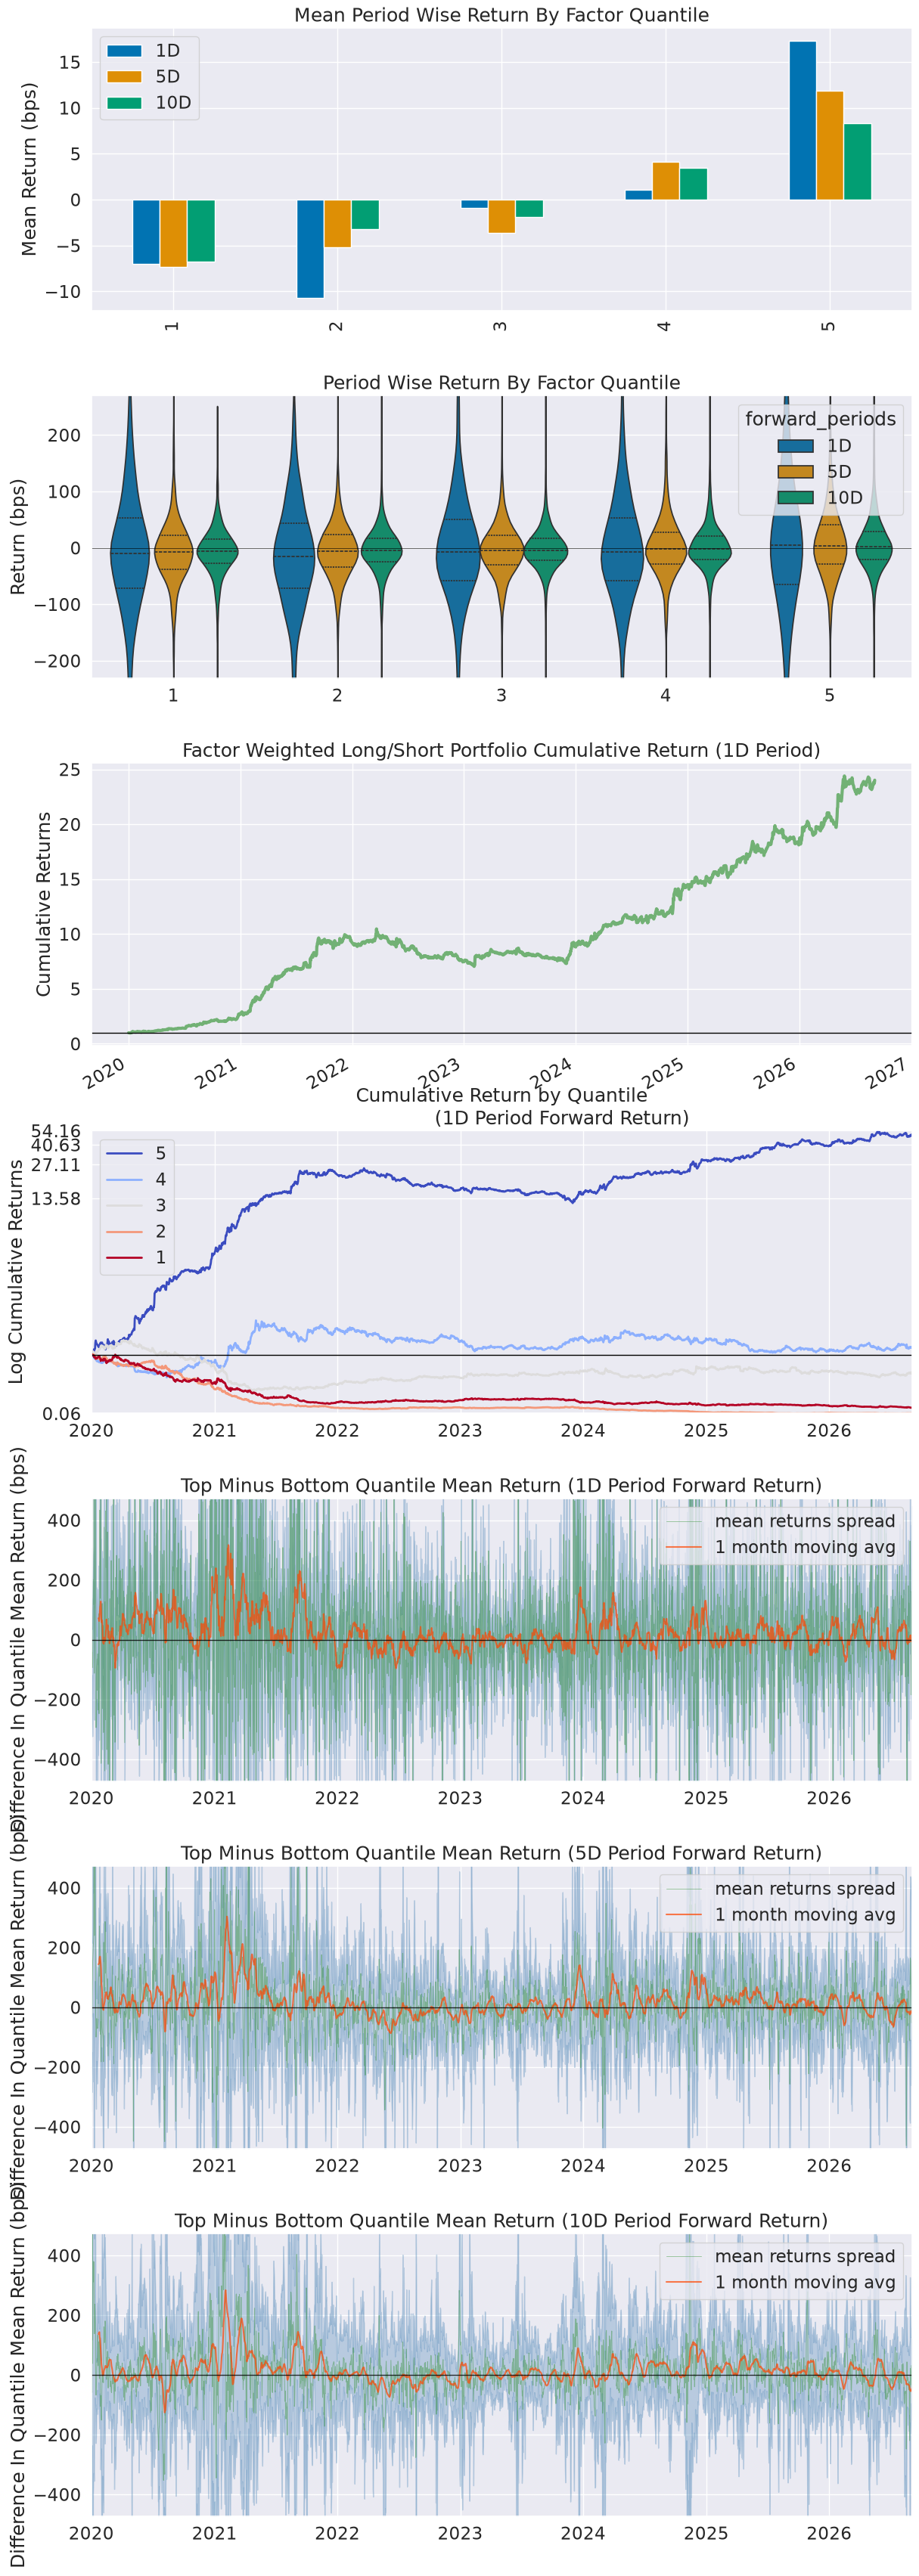

Information Analysis


,1D,5D,10D
IC Mean,0.011,0.022,0.026
IC Std.,0.212,0.203,0.199
Risk-Adjusted IC,0.051,0.109,0.131
t-stat(IC),2.512,5.381,6.480
p-value(IC),0.012,0.000,0.000
IC Skew,-0.109,-0.002,-0.092
IC Kurtosis,-0.147,-0.121,-0.123


/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/alphalens/performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


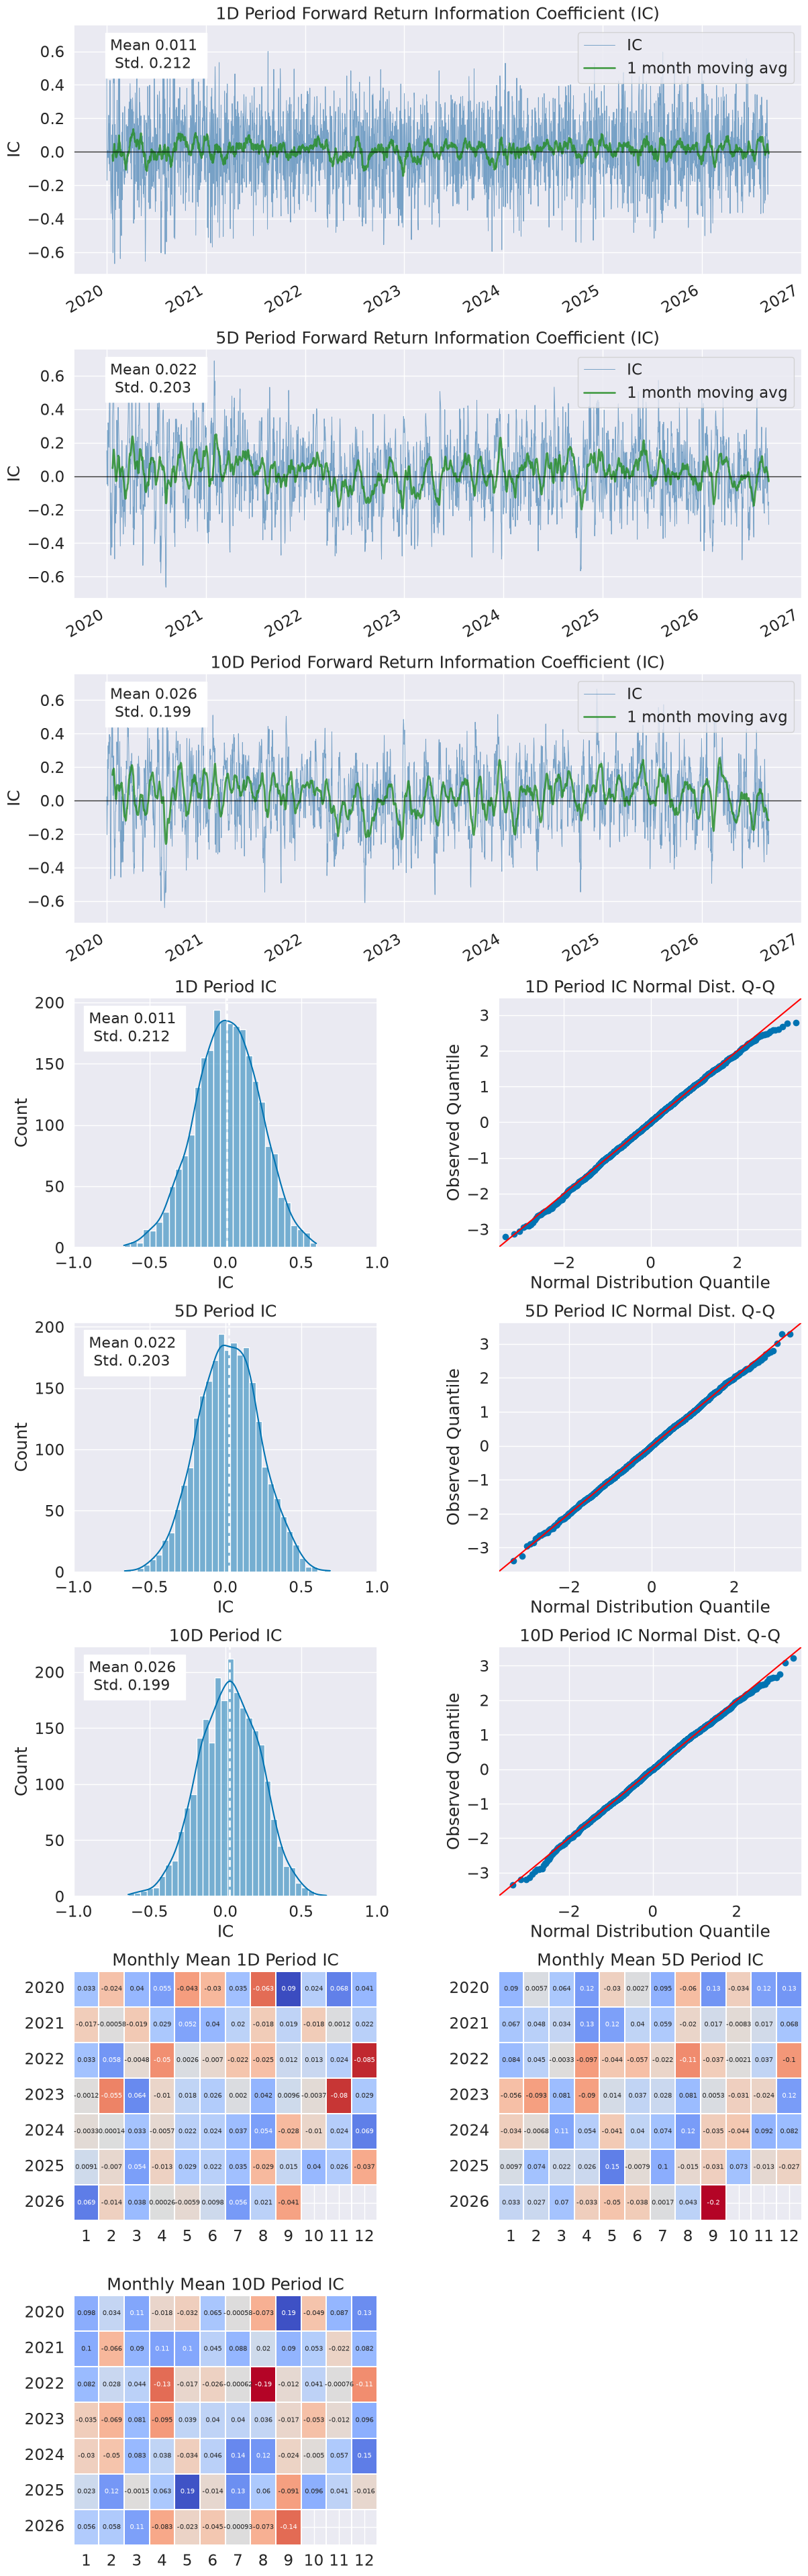

/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.396,0.619,0.726
Quantile 2 Mean Turnover,0.542,0.717,0.777
Quantile 3 Mean Turnover,0.553,0.733,0.781
Quantile 4 Mean Turnover,0.493,0.714,0.779
Quantile 5 Mean Turnover,0.259,0.524,0.671


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.796,0.461,0.234


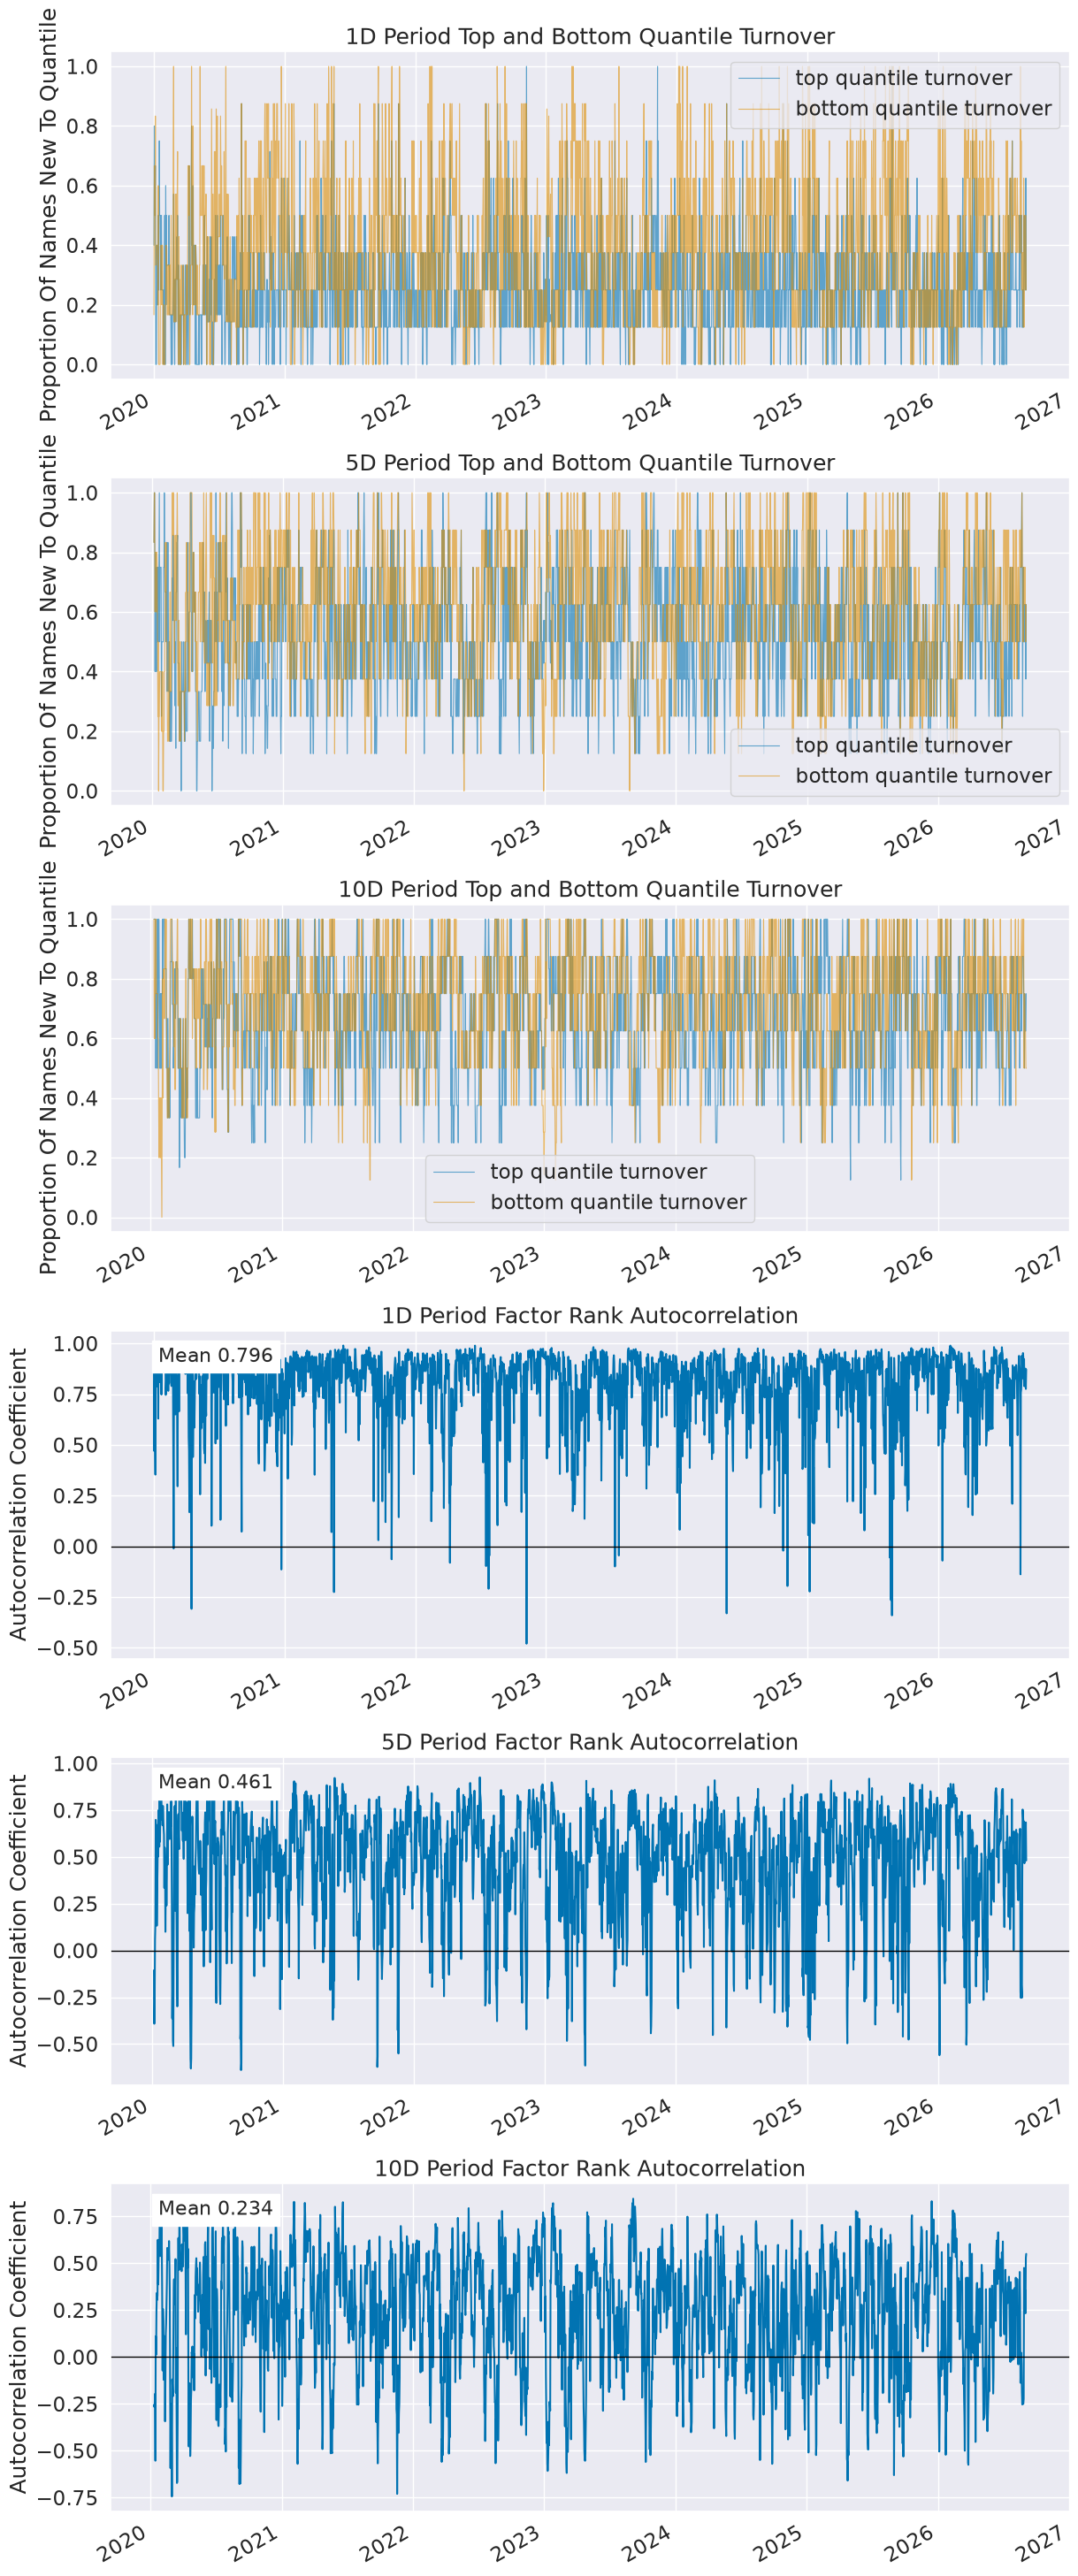

In [1]:
# AUTO-GENERATED from scripts/factors_catalog.py by
# scripts/generate_factor_notebooks.py -- do not edit by hand.
import sys
from pathlib import Path

_root = Path.cwd()
while not (_root / "notebooks" / "analysis").is_dir() and _root != _root.parent:
    _root = _root.parent
for _p in (_root, _root / "notebooks"):
    sys.path.insert(0, str(_p))

from unravel_client import (
    get_historical_universe,
    get_portfolio_factors_historical,
    get_prices,
    get_tickers,
)

from analysis.alphalens import factor_analysis
from analysis.utils import get_env

UNRAVEL_API_KEY = get_env("UNRAVEL_API_KEY")

# Instantaneous Volatility -- portfolio instantaneous_volatility.40
portfolio = "instantaneous_volatility"
universe_size = "40"

available_tickers = get_tickers(
    id=portfolio,
    api_key=UNRAVEL_API_KEY,
    universe_size=universe_size,
    exchange=None,
)
historical_factors = get_portfolio_factors_historical(
    id=portfolio, tickers=available_tickers, api_key=UNRAVEL_API_KEY
)
underlying = get_prices(tickers=available_tickers, api_key=UNRAVEL_API_KEY)

# Mask the raw factor with the dynamic point-in-time universe (a boolean
# dates x tickers matrix) so AlphaLens scores only the universe we trade,
# not every ticker that was ever tradeable.
universe = get_historical_universe(
    size=universe_size,
    api_key=UNRAVEL_API_KEY,
    start_date=str(historical_factors.index.min().date()),
    end_date=str(historical_factors.index.max().date()),
)
membership = (
    universe.reindex(index=historical_factors.index)
    .ffill()
    .reindex(columns=historical_factors.columns)
    .fillna(False)
    .astype(bool)
)
restricted_factors = historical_factors.where(membership)

columns_intersection = restricted_factors.columns.intersection(underlying.columns)
factor_analysis(restricted_factors[columns_intersection], underlying)